In [1]:
import librosa 
from pathlib import Path
import numpy as np 
import soundfile as sf
from scipy.io import wavfile
from IPython.display import Audio


In [2]:
path = '/mindhive/mcdermott/www/mturk_stimuli/imgriff/single_word_rec/pilot'

# use resampled words for this: 
wav_paths = list(Path(path, 'giga_200_words').glob('*.wav'))

In [3]:
np.random.seed(1234)

In [4]:

next_pow_2 = lambda x: int(pow(2, np.ceil(np.log2(x))))

def combine_with_noise(clean, noise, snr):
    # get ratio in rms 
    rms_ratio = np.power(10.0, snr / 20.0)
    
    # remove DC of each signal
    clean = clean - clean.mean()
    noise = noise - noise.mean()
    # get rms of each signal
    clean_rms = np.sqrt(np.mean(np.power(clean, 2)))
    noise_rms = np.sqrt(np.mean(np.power(noise, 2)))
    # scale factor for setting noise to desired SNR 
    scale_factor = clean_rms / (noise_rms * rms_ratio)
    # Blend signals 
    noise = noise * scale_factor
    mixture = clean + noise[:len(clean)]
    return mixture 

def rms_normalize(wav, new_rms=0.07): # value used with clean words
    wav = wav - wav.mean()
    rms_wav = np.sqrt(np.mean(np.power(wav, 2)))
    wav = wav * new_rms / rms_wav
    return wav
    

def get_noise(X, n_fft):
    noise_mag = X * np.exp(
        2*np.pi*1j*np.random.random(len(X)))
    noise = np.real(np.fft.irfft(noise_mag, n_fft))    
    return noise 


In [5]:
# Get wavs to use and pad if needed 

concat_wavs = [librosa.load(wav,sr=16000)[0] for wav in wav_paths]

for ix, wav in enumerate(concat_wavs):
    if wav.shape[0] != (1.75 * 16000):
        pad_len = int((1.75 * 16000) - wav.shape[0])
        concat_wavs[ix] = np.pad(wav, (0, pad_len), mode='constant', constant_values=0)

concat_wavs = np.array(concat_wavs)

In [7]:
# noise = rms_normalize(noise)
# wav = rms_normalize(wav)

# rel_to_noise = combine_with_noise(noise[:len(wav)], wav, +5)
# rel_to_clean = combine_with_noise(wav, noise, -5)

# print(np.sqrt(np.mean(np.power(rel_to_noise, 2))))
# print(np.sqrt(np.mean(np.power(rel_to_clean, 2))))


NameError: name 'noise' is not defined

In [ ]:
Audio(noise, rate=16000)

In [ ]:
Audio(rel_to_noise, rate=16000)

In [ ]:
Audio(rel_to_clean, rate=16000)

## Get average magnitude spectrum of speech

In [8]:
nfft = next_pow_2(concat_wavs.shape[-1]) #int(0.025 * 16000 )
X = np.abs(np.fft.rfft(concat_wavs, n=nfft, axis=-1)).mean(0)


In [9]:
%matplotlib inline 
import matplotlib.pyplot as plt 

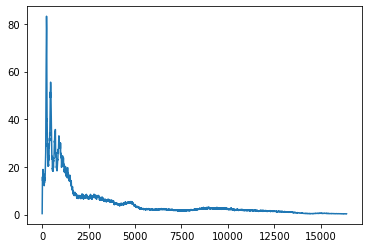

In [10]:
plt.plot(X)

In [28]:
snr_low = -5 # in dB

snr_high = 0 # in dB

low_path = Path(path, 'giga_200_-5_snr')
high_path = Path(path, 'giga_200_0_snr')

if not low_path.is_dir():
    low_path.mkdir()
    
if not high_path.is_dir():
    high_path.mkdir()
    
for wav_path in wav_paths[1:]:
    wav_name = wav_path.name
    wav, sr = librosa.load(wav_path, sr=16000)
    # compute noise using computed average spectrum X 
    noise = get_noise(X, nfft)       
    mix_low = combine_with_noise(wav, noise, snr_low)
    print(np.sqrt(np.mean(np.power(mix_low, 2))))
    mix_low = rms_normalize(mix_low)
    print(np.sqrt(np.mean(np.power(mix_low, 2))))

#     low_name = Path(low_path, f'snr_{snr_low}_{wav_path.name}')
#     sf.write(low_name, mix_low, sr, subtype='PCM_16')
    
    # get new noise for new SNR
    noise = get_noise(X, nfft)   
    mix_high = combine_with_noise(wav, noise, snr_high)
    print(np.sqrt(np.mean(np.power(mix_high, 2))))
    break
#     high_name = Path(high_path, f'snr_{snr_high}_{wav_path.name}')
#     sf.write(high_name, mix_high, sr, subtype='PCM_16') 
    
    


0.1412246940187134
0.06999999999999999
0.09845602631238347


In [29]:
wav_path

PosixPath('/mindhive/mcdermott/www/mturk_stimuli/imgriff/single_word_rec/pilot/giga_200_words/Day.wav')

([], [])

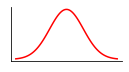

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import math
import seaborn as sns

plt.figure(figsize=(2,1))
mu = 0
variance = 1
sigma = math.sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r')
sns.despine()
plt.xticks([])
plt.yticks([])

/om4/group/mcdermott/user/imgriff/conda_envs_files/pytorch_ASR/lib/python3.9/site-packages/matplotlib/cbook/__init__.py:1333: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


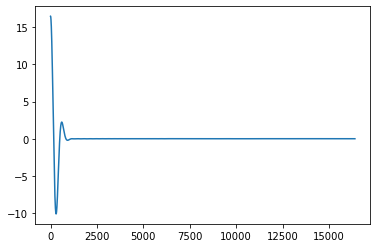

In [50]:
fft_g = np.fft.rfft(stats.norm.pdf(x, mu, sigma), n=nfft)


(-1399.95, 29398.95, -1.07691650390625, 0.80927734375)

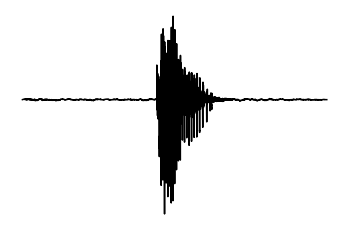

In [30]:
plt.plot(wav,'k')
plt.axis('off')

(-1638.3500000000001, 34405.35, -0.233672257808209, 0.20917144328163836)

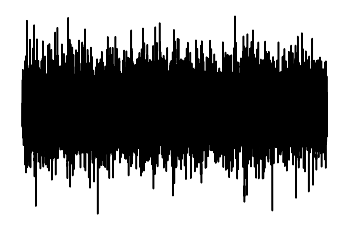

In [26]:
plt.plot(noise,'k')
plt.axis('off')

(-1399.95, 29398.95, -1.0472057923404319, 0.8627134752389538)

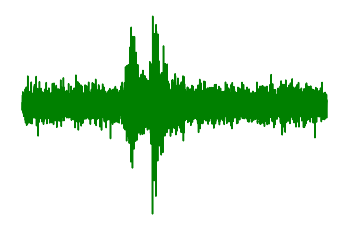

In [21]:
plt.plot(mix_high,'g')
plt.axis('off')

(-1399.95, 29398.95, -0.4333163999213951, 0.4597878779315012)

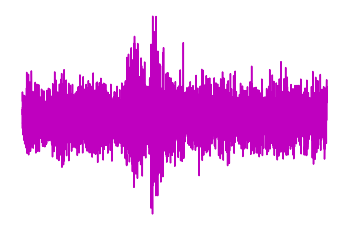

In [25]:
plt.plot(mix_low,'m')
plt.axis('off')

## Example mixes

In [35]:
Audio(mix_low, rate=16000)

In [29]:
high_snr = high_path.glob('*.wav')

In [36]:
wav, sr = librosa.load(next(high_snr),sr=16000)
Audio(wav, rate=16000)

In [32]:
low_snr = low_path.glob('*.wav')

In [33]:
wav, sr = librosa.load(next(low_snr),sr=16000)
Audio(wav, rate=16000)